Title and Introduction
# PageRank Algorithm: Implementation and Mathematical Analysis

## 1. Introduction
The internet is a vast, interconnected network of information. In the early days of the web, finding relevant information was incredibly difficult because search engines primarily ranked pages based on keyword density. The PageRank algorithm, developed by Larry Page and Sergey Brin, revolutionized this process by evaluating the quality and quantity of links to a webpage to determine a relative score of that page's importance and authority. 

This project explores the mathematical underpinnings of PageRank, demonstrating how a real-world problem—information retrieval and ranking—can be translated into a mathematical counterpart and solved programmatically.

Problem Formulation
## 2. Problem Formulation and Significance

**The Real-World Problem:** Given billions of web pages, how can a search engine determine which pages are the most authoritative and relevant to display first? 

**The Mathematical Translation:**
We can model the World Wide Web as a massive directed graph. In this graph, each web page is a node, and each hyperlink from one page to another is a directed edge. The core assumption of PageRank is that more important websites are likely to receive more links from other websites. Therefore, the problem of ranking web pages transforms into the mathematical problem of finding the steady-state probability distribution of a random surfer clicking links on this directed graph. 

Understanding and solving this problem is highly significant, as it forms the foundational logic for modern search engines and network analysis.

Project Scope and Objectives
## 3. Project Scope and Objectives

The objective of this notebook is to build the PageRank algorithm from scratch and analyze its behavior. Specifically, this project will cover:

* **Mathematical Foundation:** Explaining the linear algebra behind the algorithm, including transition matrices, Markov chains, and eigenvectors.
* **Data Simulation:** Generating localized, mock network graphs to serve as our web environment.
* **Algorithm Implementation:** Writing a functional Python implementation of the iterative PageRank algorithm.
* **Analysis and Validation:** Testing the algorithm's convergence, analyzing the impact of the damping factor ($d$), and discussing edge cases like "spider traps" and "dead ends."


In [2]:
%pip install numpy networkx matplotlib

   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/12.3 MB 8.4 MB/s eta 0:00:02
   ---------- ----------------------------- 3.1/12.3 MB 7.8 MB/s eta 0:00:02
   -------------- ------------------------- 4.5/12.3 MB 7.4 MB/s eta 0:00:02
   ------------------- -------------------- 6.0/12.3 MB 7.3 MB/s eta 0:00:01
   ---------------------- ----------------- 7.1/12.3 MB 7.0 MB/s eta 0:00:01
   -------------------------- ------------- 8.1/12.3 MB 6.7 MB/s eta 0:00:01
   ----------------------------- ---------- 9.2/12.3 MB 6.6 MB/s eta 0:00:01
   ---------------------------------- ----- 10.7/12.3 MB 6.5 MB/s eta 0:00:01
   -------------------------------------- - 11.8/12.3 MB 6.6 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 6.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----------------------------------- ---- 1.8/2.1 MB 9.2 MB/s eta 0:00:01
   ---------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

np.random.seed(42)

print("Libraries successfully imported. Environment ready for PageRank implementation.")

Libraries successfully imported. Environment ready for PageRank implementation.


Transition Matrices
## 4. Mathematical Foundation

To compute the PageRank of a network, we must translate our web graph into a mathematical structure. We do this using a **Transition Matrix** (often denoted as $M$). 

Let $N$ be the total number of pages on our web graph. The matrix $M$ is an $N \times N$ matrix where each column represents a web page, and each row represents an outgoing link. 

If page $j$ has $L(j)$ outgoing links, the probability of a user clicking any specific link on that page is $\frac{1}{L(j)}$. Therefore, the entries of our transition matrix are defined as:

$$M_{ij} = \begin{cases} \frac{1}{L(j)} & \text{if page } j \text{ links to page } i \\ 0 & \text{otherwise} \end{cases}$$

This creates a "column stochastic matrix," meaning the sum of probabilities in every column equals 1 (assuming the page has at least one outgoing link).

The Damping Factor
### 4.1. The Random Surfer Model and Damping Factor

If a user endlessly clicks links, what happens if they reach a page with no outgoing links (a "dead end") or a group of pages that only link to each other (a "spider trap")? They would get stuck, and the math would break.

To solve this, Larry Page and Sergey Brin introduced the **Random Surfer Model** and the **Damping Factor** ($d$). 

The damping factor represents the probability that a user will continue clicking links. The value $(1 - d)$ represents the probability that the user gets bored and "teleports" to a completely random page in the network. Traditionally, $d$ is set to $0.85$.

Taking the damping factor into account, the PageRank $PR$ of a specific page $p_i$ is calculated as:

$$PR(p_i) = \frac{1-d}{N} + d \sum_{p_j \in M(p_i)} \frac{PR(p_j)}{L(p_j)}$$

Where $M(p_i)$ is the set of all pages that link to $p_i$.

Eigenvectors
### 4.2. Eigenvector Centrality

While the iterative summation above is intuitive, the most efficient way to compute PageRank mathematically is by finding the steady-state of the network.

If we represent the PageRank of all pages as a column vector $v$, the PageRank equation for the entire network can be expressed as:

$$v = \left( \frac{1-d}{N} E + d M \right) v$$

Where $E$ is an $N \times N$ matrix of ones. This equation essentially states that the PageRank vector $v$ is the **principal eigenvector** of the modified transition matrix, corresponding to an eigenvalue of 1. By repeatedly multiplying our transition matrix by our rank vector (the Power Iteration method), the values will eventually converge to this steady-state eigenvector.

Data Simulation Explanation
## 5. Data Simulation: Building a Network Graph

To test our PageRank algorithm, we need a network of web pages. [cite_start]As per the project guidelines, data for our analysis may be generated or simulated. 

We will use the `networkx` library to construct a small, directed graph representing five hypothetical web pages (A, B, C, D, and E). 

**Network Structure:**
* **Page A** is a highly referenced page (receives many links).
* **Page B** and **Page C** link back and forth to each other and to A.
* **Page D** only links to Page A.
* **Page E** is somewhat isolated, linking only to Page D.

Let's build and visualize this directed graph.

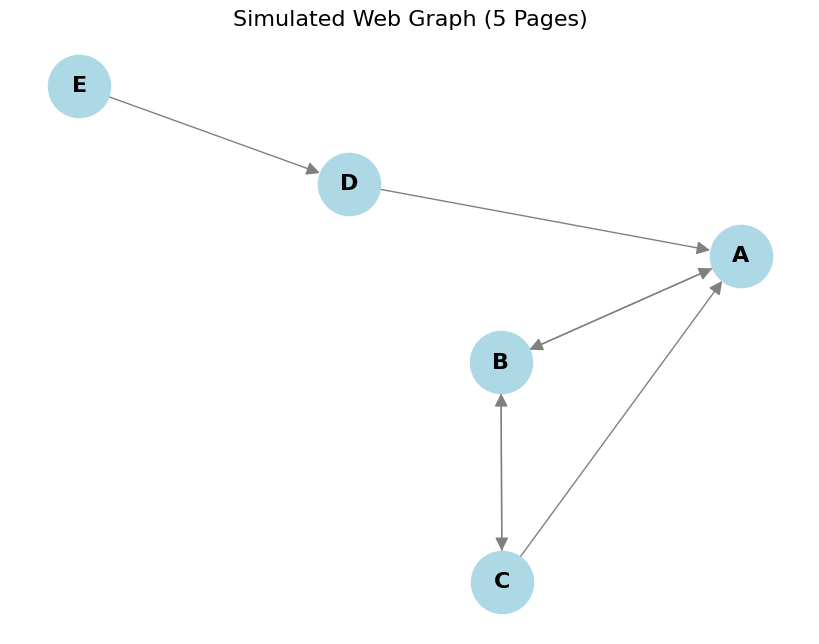

In [5]:
# Network Generation & Visualization
G = nx.DiGraph()


edges = [
    ('B', 'A'), ('B', 'C'),
    ('C', 'A'), ('C', 'B'),
    ('D', 'A'),
    ('E', 'D'),
    ('A', 'B') ]

G.add_edges_from(edges)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42) 

nx.draw(
    G, pos, 
    with_labels=True, 
    node_color='lightblue', 
    node_size=2000, 
    font_size=16, 
    font_weight='bold', 
    edge_color='gray', 
    arrowsize=20
)

plt.title("Simulated Web Graph (5 Pages)", fontsize=16)
plt.show()